**Loading the dataset: CIFAR-10**

We will use the CIFAR-10 dataset for training and testing (https://www.cs.toronto.edu/~kriz/cifar.html).

In [8]:
# import section
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow import keras
from tensorflow.keras import layers, Input, Model, Sequential

from sklearn.metrics import confusion_matrix
import seaborn as sns

from tensorflow.keras.callbacks import EarlyStopping

In [9]:
# load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

**Visualize the data**

<Figure size 393.701x393.701 with 0 Axes>

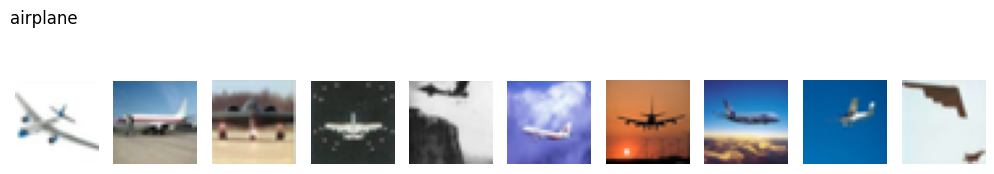

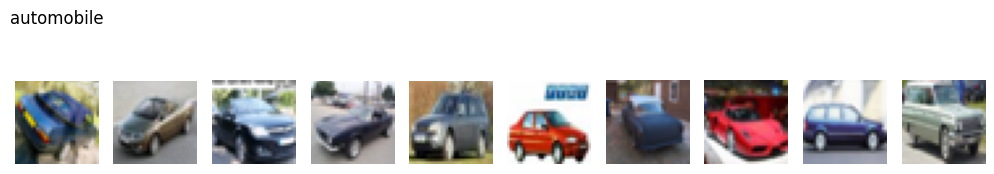

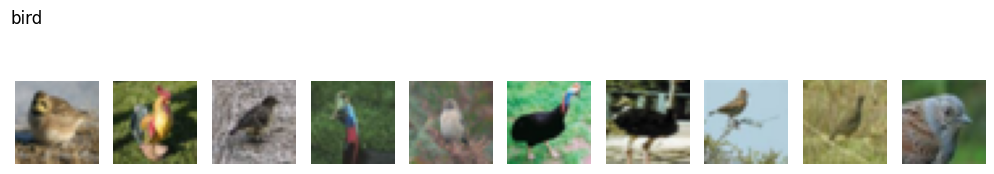

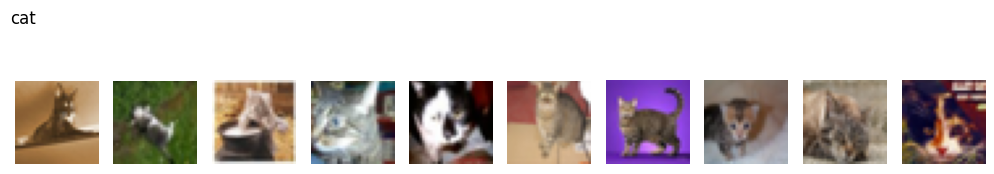

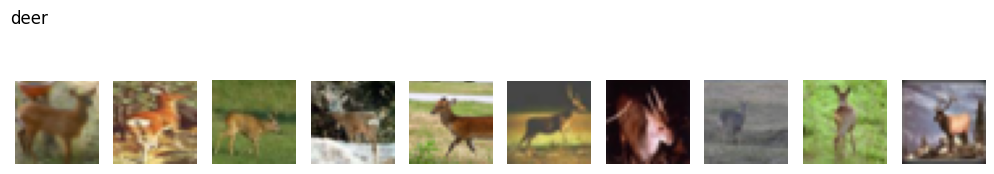

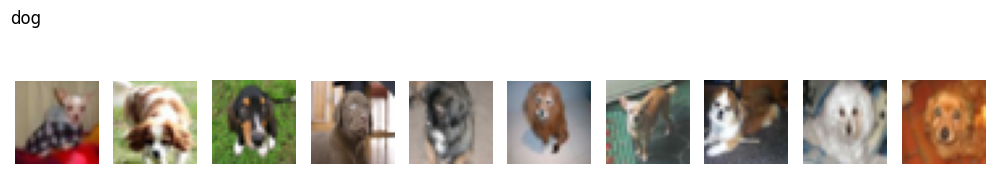

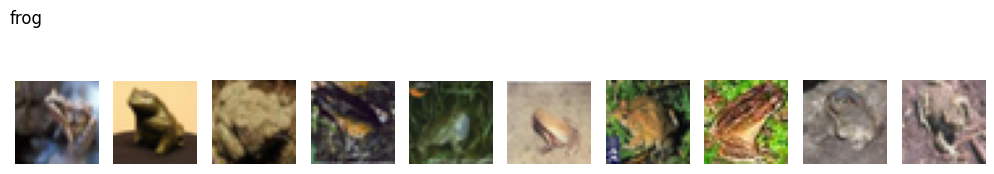

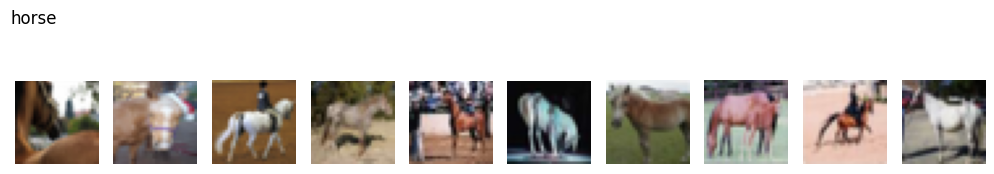

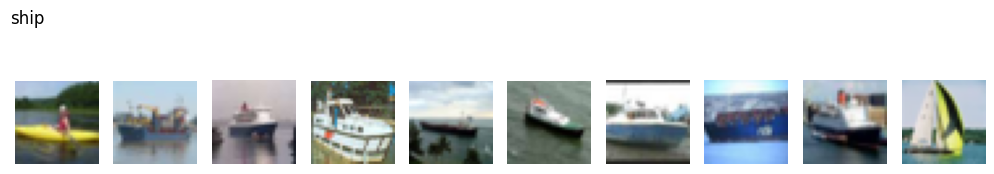

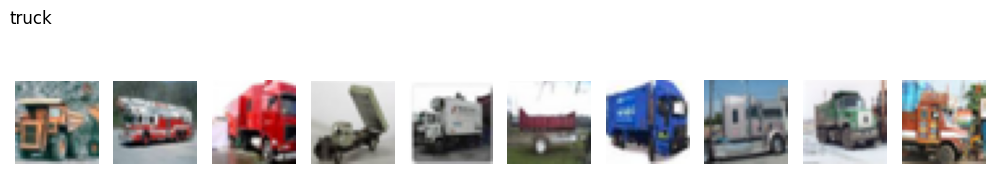

In [10]:
#print(x_train.shape)

# define the classes of the CIFAR-10 dataset
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# number of classes of the CIFAR-10 dataset
num_classes = len(labels)

# prepare and display 10 pictures for each class
fig = plt.figure(figsize=(10*1/2.54, 10*1/2.54))

for idx_class in range(num_classes):

  all_idx = np.where(y_train.flatten() == idx_class)[0]

  # random selection of 10 image of each class
  rand_idx = np.random.choice(all_idx, size=10, replace=False)
  selected = x_train[rand_idx]

  plt.figure(figsize=(10, 2))

  # add class label (left side of the row)
  plt.suptitle(f"{labels[idx_class]}", fontsize=12, x=0.01, ha="left")
  #plt.text(-0.1, 0.5, labels[idx_class], fontsize=10, va='center', ha='right', transform=plt.gca().transAxes)

  for i in range(10):
    ax = plt.subplot(1, 10, i+1)
    plt.imshow(selected[i])
    ax.axis("off")

  plt.tight_layout()

  plt.show()

**Data normalization**

In [11]:
x_test_in = x_test

# normalize the data for both x_train and x_test
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


**Prepare the labels**

In [12]:
y_test_in = y_test

# transform both y_train and y_test to categorical form
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


**Define the model**

In [13]:
input_shape = (32, 32, 3)

#my_reg = keras.regularizers.l2(0.0001)

def residual_block(x, filters):
  shortcut = x

  # first convolution
  x = layers.Conv2D(filters, (3,3), padding="same", activation='relu')(x)
  x = layers.BatchNormalization()(x)

  # second convolution
  x = layers.Conv2D(filters, (3,3), padding="same")(x)
  x = layers.BatchNormalization()(x)

  # shortcut
  x = layers.Add()([x, shortcut])
  x = layers.ReLU()(x)

  return x

def build_resnet_model(input_shape=(32,32,3), num_classes=10):
  inputs = Input(shape=input_shape)

  # data augmentation
  x = layers.RandomFlip("horizontal")(inputs)
  x = layers.RandomTranslation(0.125, 0.125)(x)

  # block 1: 32 filters
  x = layers.Conv2D(32, (3,3), padding="same", activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = residual_block(x, 32)
  x = layers.MaxPooling2D()(x)
  x = layers.Dropout(0.15)(x)

  # block 2: 64 filters
  x = layers.Conv2D(64, (3,3), padding="same", activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = residual_block(x, 64)
  x = layers.MaxPooling2D()(x)
  x = layers.Dropout(0.20)(x)

  # block 3: 128 filters
  x = layers.Conv2D(128, (3,3), padding="same", activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = residual_block(x, 128)
  x = layers.MaxPooling2D()(x)
  x = layers.Dropout(0.30)(x)

  # classifier
  x = layers.Flatten()(x)
  x = layers.Dense(256, activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(0.40)(x)

  outputs = layers.Dense(num_classes, activation="softmax")(x)

  model = Model(inputs, outputs)

  return model

model_resnet = build_resnet_model()

# show details of the model
model_resnet.summary()

model1 = model_resnet

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 32, 32, 3) │          0 │ random_flip[0][0] │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ random_translati… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_4[0][0]  

 Total params: 1,011,594 (3.86 MB)

 Trainable params: 1,009,738 (3.85 MB)

 Non-trainable params: 1,856 (7.25 KB)

**Compile the model**

In [14]:
import time

#my_SGD = keras.optimizers.SGD(learning_rate=0.001)
#my_Adam = keras.optimizers.Adam(learning_rate=0.005)
#my_SGD = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# compile the model with Adap optimizer
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#model1.compile(loss='categorical_crossentropy', optimizer=my_SGD, metrics=['accuracy'])

# fit the model; measure the fit time
start = time.time()
history = model1.fit(x_train, y_train, batch_size=512, epochs=100, validation_split=0.1, callbacks=[early_stop])
end = time.time()

# display the fit time
total_time = end - start
print("Training time:", total_time, "seconds")

# display the average fit time per epoch
epochs = len(history.history['loss'])
avg_time = total_time / epochs
print("Average time per epoch:", avg_time, "seconds")

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 183ms/step - accuracy: 0.2846 - loss: 2.2820 - val_accuracy: 0.0978 - val_loss: 3.0094
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.4743 - loss: 1.4808 - val_accuracy: 0.1548 - val_loss: 3.5721
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.5541 - loss: 1.2625 - val_accuracy: 0.1808 - val_loss: 3.4033
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 153ms/step - accuracy: 0.6028 - loss: 1.1093 - val_accuracy: 0.2510 - val_loss: 2.9413
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - accuracy: 0.6462 - loss: 1.0023 - val_accuracy: 0.4904 - val_loss: 1.4954
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - accuracy: 0.6794 - loss: 0.9018 - val_accuracy: 0.6644 - val_loss: 0.9624
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.7032 - loss: 0.8469 - val_accuracy: 0.7516 - val_loss: 0.7176
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.7232 - loss: 0.7851 - 

In [15]:
# display the accuracies for the train and validation sets
print(history.history.keys())

print("Train accuracy:", history.history["accuracy"][-1])
print("Validation accuracy:", history.history["val_accuracy"][-1])

# display the losses for the train and validation sets

print("Train loss:", history.history["loss"][-1])
print("Validation loss:", history.history["val_loss"][-1])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Train accuracy: 0.8804222345352173
Validation accuracy: 0.8398000001907349
Train loss: 0.35122641921043396
Validation loss: 0.5046559572219849


**Evaluate the model**

Test accuracy: 0.8511999845504761
Test loss: 0.4603368639945984
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


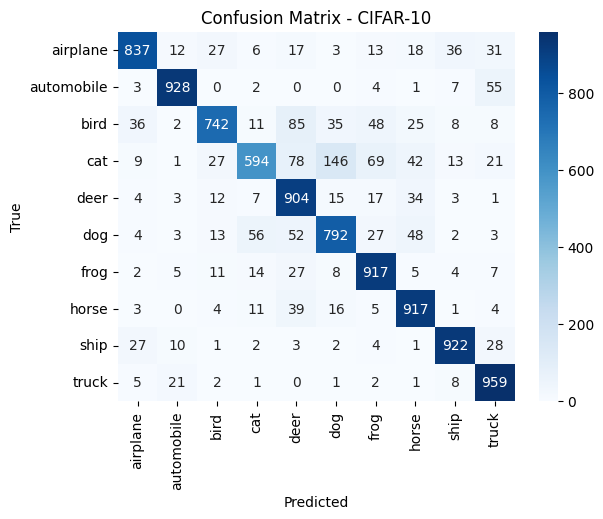

In [16]:
# evaluate the model and print the test accuracy and loss
score = model1.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", score[1])
print("Test loss:", score[0])

# prepare and display the confusion matrix for the testing set
y_test_pred_prob = model1.predict(x_test)
y_test_pred = y_test_pred_prob.argmax(axis=1)

conf_matr = confusion_matrix(y_test.argmax(axis=1), y_test_pred)

sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CIFAR-10")
plt.show()

**Check the pictures that were wrongly categorized**

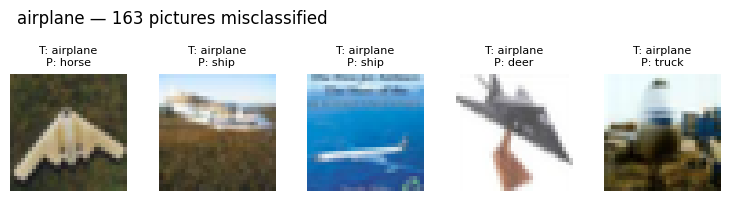

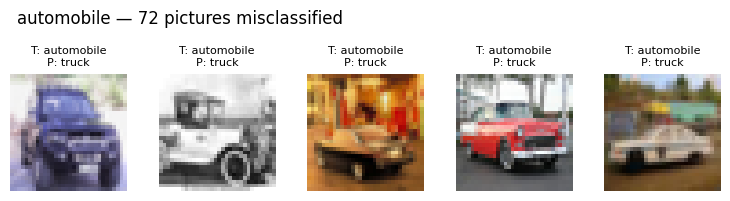

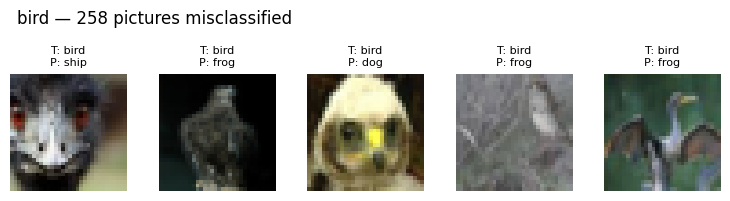

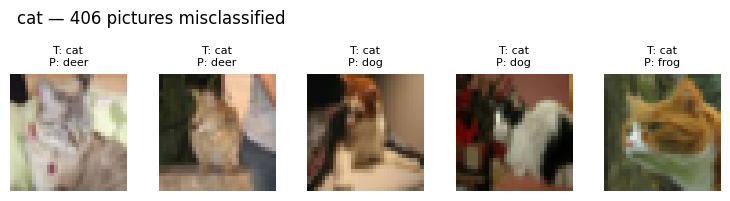

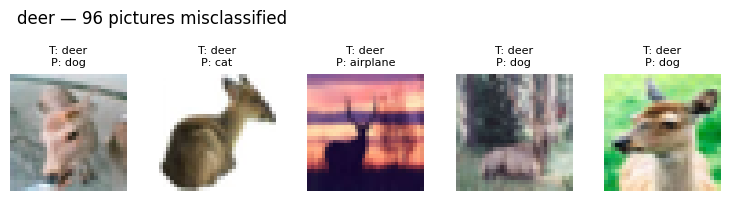

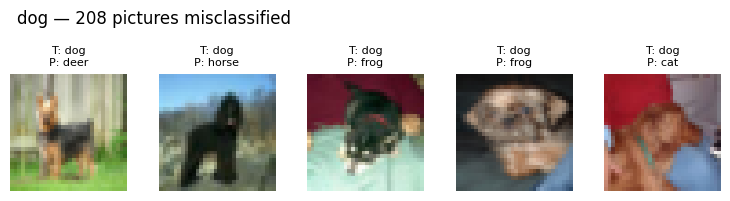

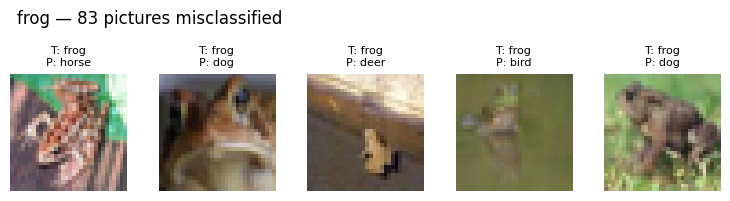

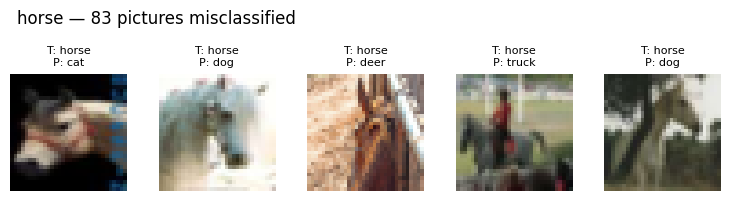

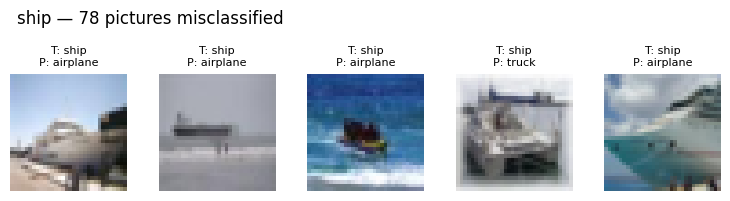

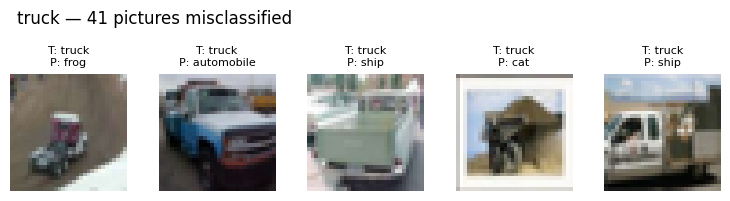

In [17]:
# the number of wrong predicted photos per class to be displayed
max_per_class = 5

# check the positions where the predictions were wrong
y_test_in_r = y_test_in.ravel()
idx_diff = np.where(y_test_pred != y_test_in_r)[0]

# separate the wrongly predicted idx per classes
diff_by_class = {i: [] for i in range(len(labels))}
for idx in idx_diff:
  true_label = y_test_in_r[idx]
  diff_by_class[true_label].append(idx)

for class_id, class_name in enumerate(labels):
  idx_list = diff_by_class[class_id]
  if len(idx_list) == 0:
    continue

  # display a maximum number of missclassified photos per class (5)
  n = len(idx_list)
  idx_list = idx_list[:max_per_class]
  cols = num_classes
  rows = 1
  plt.figure(figsize=(cols * 1.5, 2))
  plt.suptitle(f"{class_name} — {n} pictures misclassified", fontsize=12, x=0.02, ha="left")

  for i, idx in enumerate(idx_list):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    pred_label = labels[y_test_pred[idx]]
    plt.title(f"T: {class_name}\nP: {pred_label}", fontsize=8)

  plt.tight_layout(rect=[0, 0, 1, 0.9])
  plt.show()


**Save the model to file**

In [19]:
import os

#print("Working directory:", os.getcwd())
#print("Files here:", os.listdir())

# save the trained model
model1.save("cifar10.model17.keras")